In [1]:
!pip install -U pandas openpyxl numpy matplotlib scikit-learn
!pip install -U ydata-profiling
!pip install -U pandera
!pip install -U dvc
!pip install -U mlflow

  Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl (9.8 MB)
Using cached numpy-2.5.2-cp313-cp313-win_amd64.whl (12.5 MB)
Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl (9.3 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 2.3.5

   ---------------------------------------- 0/3 [numpy]
    Uninstalling numpy-2.3.5:
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
      Successfully uninstalled numpy-2.3.5
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [nu

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.5.2 which is incompatible.
ydata-profiling 4.18.4 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.11.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.5.2 which is incompatible.
ydata-profiling 4.18.4 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.5 which is incompatible.


  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached matplotlib-3.10.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl (12.8 MB)
Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl (11.0 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 2.5.2

   ---------------------------------------- 0/3 [numpy]
    Uninstalling numpy-2.5.2:
   ---------------------------------------- 0/3 [numpy]
      Successfully uninstalled numpy-2.5.2
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [nu

In [2]:
mlflow ui

SyntaxError: invalid syntax (3574192917.py, line 1)

In [3]:
import os 
folders = [
    "salary_mlops",
    "salary_mlops/data/raw",
    "salary_mlops/data/processed",
    "salary_mlops/data/features",
    "salary_mlops/reports",
    "salary_mlops/models",
    "salary_mlops/src",
    "salary_mlops/mlruns",
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)
print("Project structure created successfully.")
    

Project structure created successfully.


In [4]:
import pandas as pd
import os

excel_file = "Salary Data.xlsx"

df = pd.read_excel(excel_file)

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (375, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']


In [6]:
print("Data Types:")
print(df.dtypes)

Data Types:
Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object


In [7]:
df.info

<bound method DataFrame.info of       Age  Gender Education Level                      Job Title  \
0    32.0    Male      Bachelor's              Software Engineer   
1    28.0  Female        Master's                   Data Analyst   
2    45.0    Male             PhD                 Senior Manager   
3    36.0  Female      Bachelor's                Sales Associate   
4    52.0    Male        Master's                       Director   
..    ...     ...             ...                            ...   
370  35.0  Female      Bachelor's       Senior Marketing Analyst   
371  43.0    Male        Master's         Director of Operations   
372  29.0  Female      Bachelor's         Junior Project Manager   
373  34.0    Male      Bachelor's  Senior Operations Coordinator   
374  44.0  Female             PhD        Senior Business Analyst   

     Years of Experience    Salary  
0                    5.0   90000.0  
1                    3.0   65000.0  
2                   15.0  150000.0  
3  

In [9]:
raw_path = "salary_mlops/data/raw/salary_data.xlsx"
df.to_excel(raw_path,index=False)
print("Raw dataset saved at:")
print(raw_path)

Raw dataset saved at:
salary_mlops/data/raw/salary_data.xlsx


In [10]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [11]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [12]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Years of Experience"] = df["Years of Experience"].fillna(
    df["Years of Experience"].median()
)

df["Salary"] = df["Salary"].fillna(df["Salary"].median())

In [13]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Education Level"] = df["Education Level"].fillna(
    df["Education Level"].mode()[0]
)

df["Job Title"] = df["Job Title"].fillna(
    df["Job Title"].mode()[0]
)

In [14]:
df.duplicated().sum()

np.int64(50)

In [15]:
numerical_columns = [
    "Age",
    "Years of Experience"
]

In [16]:
categorical_columns = [
    "Gender",
    "Education Level",
    "Job Title"
]

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [20]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 50


In [21]:
print(df.shape)

(375, 6)


In [22]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_columns)
    ]
)

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

In [28]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42,
            max_depth=10
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}

print("Models created:")
for model in models:
    print(model)

Models created:
Linear Regression
Decision Tree
Random Forest
Gradient Boosting


In [33]:
# ============================================================
# EMPLOYEE SALARY PREDICTION
# COMPLETE MODEL TRAINING + EVALUATION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

file_path = "Salary Data.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Original shape:", df.shape)

# ------------------------------------------------------------
# 2. CLEAN COLUMN NAMES
# ------------------------------------------------------------

df.columns = df.columns.str.strip()

# ------------------------------------------------------------
# 3. REMOVE DUPLICATES
# ------------------------------------------------------------

df = df.drop_duplicates()

# ------------------------------------------------------------
# 4. HANDLE MISSING VALUES
# ------------------------------------------------------------

# Numerical columns
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Years of Experience"] = df["Years of Experience"].fillna(
    df["Years of Experience"].median()
)

df["Salary"] = df["Salary"].fillna(
    df["Salary"].median()
)

# Categorical columns
df["Gender"] = df["Gender"].fillna(
    df["Gender"].mode()[0]
)

df["Education Level"] = df["Education Level"].fillna(
    df["Education Level"].mode()[0]
)

df["Job Title"] = df["Job Title"].fillna(
    df["Job Title"].mode()[0]
)

# ------------------------------------------------------------
# 5. FEATURE ENGINEERING
# ------------------------------------------------------------

df["Experience_Ratio"] = (
    df["Years of Experience"] / df["Age"]
)

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 45, 60, 100],
    labels=[
        "Young",
        "Early Career",
        "Mid Career",
        "Senior",
        "Late Career"
    ]
)

# ------------------------------------------------------------
# 6. FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop("Salary", axis=1)

y = df["Salary"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget: Salary")

# ------------------------------------------------------------
# 7. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

# ------------------------------------------------------------
# 8. PREPROCESSING
# ------------------------------------------------------------

numeric_features = [
    "Age",
    "Years of Experience",
    "Experience_Ratio"
]

categorical_features = [
    "Gender",
    "Education Level",
    "Job Title",
    "Age_Group"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# ------------------------------------------------------------
# 9. DEFINE MODELS
# ------------------------------------------------------------

models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42,
            max_depth=10
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}

# ------------------------------------------------------------
# 10. TRAIN MODELS
# ------------------------------------------------------------

trained_models = {}

results = []

print("\n================ MODEL TRAINING ================\n")

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(
        X_train,
        y_train
    )

    # Store trained model
    trained_models[name] = pipeline

    # Predict
    predictions = pipeline.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"{name}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print()

# ------------------------------------------------------------
# 11. RESULTS TABLE
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

print("=============== MODEL COMPARISON ===============")

display(results_df)

# ------------------------------------------------------------
# 12. BEST MODEL
# ------------------------------------------------------------

best_model_name = results_df.loc[0, "Model"]

best_model = trained_models[best_model_name]

best_r2 = results_df.loc[0, "R2"]

print("\n================================================")
print("BEST MODEL")
print("================================================")

print("Model:", best_model_name)
print("R² Score:", round(best_r2, 4))

print("\nAll models trained successfully!")

Dataset loaded successfully!
Original shape: (375, 6)

Features:
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Experience_Ratio', 'Age_Group']

Target: Salary

Training data: (260, 7)
Testing data: (65, 7)

================ MODEL TRAINING ================

Linear Regression
  MAE  : 10444.91
  RMSE : 13952.64
  R²   : 0.9147

Decision Tree
  MAE  : 11126.13
  RMSE : 17317.38
  R²   : 0.8686

Random Forest
  MAE  : 8535.90
  RMSE : 12738.71
  R²   : 0.9289

Gradient Boosting
  MAE  : 9135.45
  RMSE : 12311.81
  R²   : 0.9336

=============== MODEL COMPARISON ===============


,Model,MAE,MSE,RMSE,R2
0,Gradient Boosting,9135.449490,1.515806e+08,12311.807383,0.933601
1,Random Forest,8535.896154,1.622747e+08,12738.708220,0.928916
2,Linear Regression,10444.906005,1.946762e+08,13952.641135,0.914723
3,Decision Tree,11126.129426,2.998915e+08,17317.375611,0.868634



BEST MODEL
Model: Gradient Boosting
R² Score: 0.9336

All models trained successfully!


Matplotlib is building the font cache; this may take a moment.


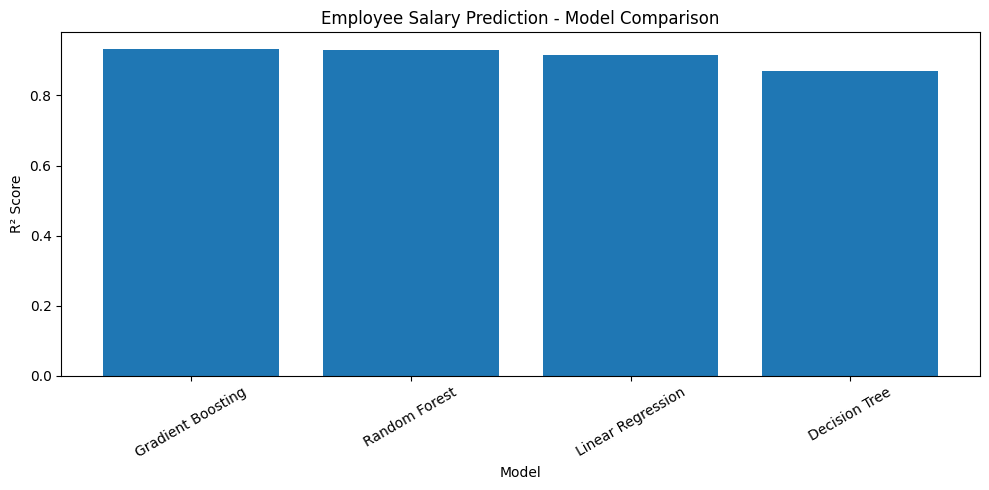

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Employee Salary Prediction - Model Comparison")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [35]:
import joblib

joblib.dump(
    best_model,
    "salary_prediction_model.pkl"
)

print("Best model saved successfully!")
print("Model:", best_model_name)

Best model saved successfully!
Model: Gradient Boosting


In [36]:
# Save processed ML-ready data

processed_file = "processed_salary_data.csv"

df.to_csv(
    processed_file,
    index=False
)

print("Processed dataset saved successfully!")
print("File:", processed_file)
print("Shape:", df.shape)

Processed dataset saved successfully!
File: processed_salary_data.csv
Shape: (325, 8)


In [37]:
# Save best model metrics

best_result = results_df.iloc[0]

metrics = {
    "best_model": best_model_name,
    "MAE": float(best_result["MAE"]),
    "MSE": float(best_result["MSE"]),
    "RMSE": float(best_result["RMSE"]),
    "R2": float(best_result["R2"])
}

import json

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved successfully!")
print(json.dumps(metrics, indent=4))

Metrics saved successfully!
{
    "best_model": "Gradient Boosting",
    "MAE": 9135.449489673203,
    "MSE": 151580601.0240572,
    "RMSE": 12311.807382511197,
    "R2": 0.9336006843550982
}


In [38]:
import mlflow
import mlflow.sklearn

print("MLflow version:", mlflow.__version__)

D:\ml projects\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow version: 3.15.1


In [39]:
trained_models
X_test
y_test

235     45000.0
110    110000.0
249    170000.0
9      110000.0
93     170000.0
         ...   
350    160000.0
233     85000.0
60     170000.0
124    140000.0
222    100000.0
Name: Salary, Length: 65, dtype: float64

In [40]:
print(trained_models.keys())

dict_keys(['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])


In [43]:
import mlflow
import mlflow.sklearn
import numpy as np

# Set MLflow experiment
mlflow.set_experiment("Employee Salary Prediction")

print("MLflow experiment ready!")

MLflow experiment ready!


In [44]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

for name, model in trained_models.items():

    with mlflow.start_run(run_name=name):

        # Make predictions
        predictions = model.predict(X_test)

        # Calculate metrics
        mae = mean_absolute_error(y_test, predictions)
        mse = mean_squared_error(y_test, predictions)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, predictions)

        # Log model name
        mlflow.set_tag("model_name", name)

        # Log metrics
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("MSE", mse)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)

        # Log trained model
        mlflow.sklearn.log_model(
            model,
            "model"
        )

        print(f"{name} logged successfully!")

2026/08/31 11:41:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/31 11:42:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear Regression logged successfully!


2026/08/31 11:42:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Decision Tree logged successfully!


2026/08/31 11:43:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest logged successfully!
Gradient Boosting logged successfully!
